# Preparing Dataset

## Normal Dataset

In [51]:
import os
import torch
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

import torchvision.transforms as T

class MyRatDataset(Dataset):
    """
    A dataset that reads images and YOLO-format annotations from a folder.
    Expected structure:
        root/
          images/
            img1.jpg
            img2.jpg
            ...
          labels/
            img1.txt
            img2.txt
            ...
    Each label file should contain lines (YOLO format):
        class_id  x_center_norm  y_center_norm  width_norm  height_norm
    In this version, we also create negative samples on the fly.
    With a certain probability, we "remove" the rat(s) by filling the bounding box regions with random noise.
    The resulting image is treated as a negative sample (with no bounding boxes).
    """
    def __init__(self, root, transforms=None, negative_sample_ratio=0.3):
        """
        Args:
            root (str): Path to the subset folder (e.g., 'new_dataset/train').
                        Must contain 'images/' and 'labels/' subfolders.
            transforms (callable, optional): Transformations to apply to the PIL image.
            negative_sample_ratio (float): The probability (0 to 1) of generating a negative sample from a positive image.
        """
        self.root = root
        self.transforms = transforms
        self.negative_sample_ratio = negative_sample_ratio
        
        self.img_dir = os.path.join(root, "images")
        self.lbl_dir = os.path.join(root, "labels")
        
        # Collect image file names
        self.imgs = [f for f in os.listdir(self.img_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        self.imgs.sort()  # for consistent ordering

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # Load image
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        # Load annotations from the corresponding label file
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.lbl_dir, label_name)
        
        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    # YOLO format: class_id, x_center, y_center, width, height (all normalized)
                    class_id = int(parts[0]) + 1
                    x_center_norm = float(parts[1])
                    y_center_norm = float(parts[2])
                    width_norm    = float(parts[3])
                    height_norm   = float(parts[4])
                    
                    # Convert normalized coords to absolute pixel coordinates
                    x_center = x_center_norm * w
                    y_center = y_center_norm * h
                    box_width = width_norm * w
                    box_height = height_norm * h
                    x_min = x_center - box_width / 2
                    y_min = y_center - box_height / 2
                    x_max = x_center + box_width / 2
                    y_max = y_center + box_height / 2
                    boxes.append([x_min, y_min, x_max, y_max])
                    labels.append(class_id)
        
        # If no annotations, treat image as a negative sample naturally
        if len(boxes) == 0:
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Decide whether to generate a negative sample from this image
        # (only if there are boxes, because otherwise it's already negative)
        if boxes.shape[0] > 0 and random.random() < self.negative_sample_ratio:
            # Generate negative sample by filling each bounding box with random noise
            img = self.generate_negative_sample(img, boxes)
            # Set target to have no boxes or labels
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
        
        image_id = torch.tensor([idx])
        if boxes.size(0) > 0:
            area = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])
        else:
            area = torch.empty((0,), dtype=torch.float32)
        iscrowd = torch.zeros((labels.shape[0],), dtype=torch.int64)
        
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }
        
        if self.transforms:
            img = self.transforms(img)
        
        return img, target

    def generate_negative_sample(self, img, boxes):
        """
        Generate a negative sample by filling the regions of each bounding box in the image with random noise.
        Args:
            img (PIL.Image): The original image.
            boxes (Tensor): Tensor of shape [N, 4] with bounding box coordinates in absolute pixel values.
        Returns:
            PIL.Image: The image with the rat regions replaced with noise.
        """
        # Convert PIL image to NumPy array
        img_np = np.array(img)
        # Iterate through each box and fill the region with random noise
        for box in boxes:
            x_min, y_min, x_max, y_max = box.int().tolist()
            # Clip coordinates to image boundaries
            x_min = max(0, x_min)
            y_min = max(0, y_min)
            x_max = min(img_np.shape[1], x_max)
            y_max = min(img_np.shape[0], y_max)
            if x_max > x_min and y_max > y_min:
                noise = np.random.randint(0, 256, (y_max - y_min, x_max - x_min, 3), dtype=np.uint8)
                img_np[y_min:y_max, x_min:x_max, :] = noise
        # Convert back to PIL image
        return Image.fromarray(img_np)

# Example usage
if __name__ == "__main__":
    import torchvision.transforms as T
    
    # Define transforms: converting image to tensor and normalizing
    transforms = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])
    
    # Create dataset instance. Adjust root path as needed.
    dataset_root = "new_dataset\\train"  # Folder with subfolders: images/ and labels/
    dataset = MyRatDataset(root=dataset_root, transforms=transforms, negative_sample_ratio=0.3)
    
    # Optionally, inspect a sample
    img, target = dataset[0]
    print("Sample target:", target)
    
    # Create DataLoader
    from torch.utils.data import DataLoader
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda batch: tuple(zip(*batch)))
    
    # Iterate over one batch
    for images, targets in dataloader:
        print(f"Batch has {len(images)} images")
        for t in targets:
            print("Boxes:", t["boxes"], "Labels:", t["labels"])
        break


Sample target: {'boxes': tensor([[ 19.0000, 133.2500, 168.0000, 396.7500]]), 'labels': tensor([1]), 'image_id': tensor([0]), 'area': tensor([39261.5000]), 'iscrowd': tensor([0])}
Batch has 4 images
Boxes: tensor([], size=(0, 4)) Labels: tensor([], dtype=torch.int64)
Boxes: tensor([[300.0000, 109.9999, 560.0000, 212.9998]]) Labels: tensor([1])
Boxes: tensor([[ 36.0000, 287.7500, 209.0000, 453.2500]]) Labels: tensor([1])
Boxes: tensor([[469.0000, 128.9998, 583.0000, 382.9999]]) Labels: tensor([1])


## Mosaic 

In [60]:
import os
import torch
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T
import cv2

class MyRatDatasetWithMosaic(Dataset):
    """
    A dataset that reads images and YOLO-format annotations from a folder and applies mosaic augmentation
    with a given probability. Additionally, it can convert the mosaic sample to a negative sample 
    (i.e. with bounding boxes removed) with a specified probability.
    
    Expected folder structure:
        root/
          images/
            img1.jpg
            img2.jpg
            ...
          labels/
            img1.txt
            img2.txt
            ...
    
    Each label file should contain lines (YOLO format):
        class_id  x_center_norm  y_center_norm  width_norm  height_norm

    The mosaic augmentation combines 4 images (2x2 grid) and adjusts bounding boxes accordingly.
    """
    def __init__(self, root, transforms=None, mosaic_prob=0.5, mosaic_negative_prob=0.5):
        """
        Args:
            root (str): Path to the subset folder (e.g., 'new_dataset/train').
                        Must contain 'images/' and 'labels/' subfolders.
            transforms (callable, optional): Transformations to apply to the PIL image.
            mosaic_prob (float): Probability to apply mosaic augmentation instead of normal sampling.
            mosaic_negative_prob (float): When mosaic augmentation is applied, probability to convert it to a negative sample.
        """
        self.root = root
        self.transforms = transforms
        self.mosaic_prob = mosaic_prob
        self.mosaic_negative_prob = mosaic_negative_prob
        
        self.img_dir = os.path.join(root, "images")
        self.lbl_dir = os.path.join(root, "labels")
        
        # Collect image file names
        self.imgs = [f for f in os.listdir(self.img_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        self.imgs.sort()  # for consistent ordering

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        if random.random() < self.mosaic_prob:
            return self.mosaic_augmentation(idx)
        else:
            return self.load_single(idx)

    def load_single(self, idx):
        """Load a single image and its labels."""
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        boxes, labels = self.load_labels(img_name, w, h)
        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.empty((0, 4), dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64) if labels else torch.empty((0,), dtype=torch.int64),
            "image_id": torch.tensor([idx]),
            "area": torch.as_tensor([(box[2]-box[0])*(box[3]-box[1]) for box in boxes], dtype=torch.float32) if boxes else torch.empty((0,), dtype=torch.float32),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64) if labels else torch.empty((0,), dtype=torch.int64)
        }
        if self.transforms:
            img = self.transforms(img)
        return img, target

    def load_labels(self, img_name, w, h):
        """Load labels for a given image."""
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.lbl_dir, label_name)
        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    # In our convention, rat's label is 1 (we add 1 to the original if it was 0)
                    class_id = int(parts[0]) + 1
                    x_center_norm = float(parts[1])
                    y_center_norm = float(parts[2])
                    width_norm    = float(parts[3])
                    height_norm   = float(parts[4])
                    
                    x_center = x_center_norm * w
                    y_center = y_center_norm * h
                    box_width = width_norm * w
                    box_height = height_norm * h
                    x_min = x_center - box_width / 2
                    y_min = y_center - box_height / 2
                    x_max = x_center + box_width / 2
                    y_max = y_center + box_height / 2
                    boxes.append([x_min, y_min, x_max, y_max])
                    labels.append(class_id)
        return boxes, labels

    def mosaic_augmentation(self, idx, input_size=640):
        """
        Creates a mosaic image from 4 images (the current index plus 3 random indices)
        and combines their bounding boxes. Optionally, converts the mosaic sample into a negative sample.
        
        Args:
            idx (int): Index of the primary image.
            input_size (int): The size to which each image is resized before mosaic.
            
        Returns:
            img (Tensor): Mosaic image (after applying transforms).
            target (dict): Combined target with adjusted bounding boxes.
        """
        # Select 3 additional indices randomly (allow repetition if necessary)
        indices = [idx] + random.sample(range(len(self)), 3)
        
        # Create a blank mosaic image (2x2 grid) and placeholders for boxes and labels.
        mosaic_img = Image.new("RGB", (input_size * 2, input_size * 2), (128, 128, 128))
        mosaic_boxes = []
        mosaic_labels = []
        
        # Random center for mosaic (within a range to allow images to be partially outside the mosaic canvas)
        xc = int(random.uniform(input_size//2, input_size*3/2))
        yc = int(random.uniform(input_size//2, input_size*3/2))
        
        for i, index in enumerate(indices):
            # Load raw image (without transforms)
            img_name = self.imgs[index]
            img_path = os.path.join(self.img_dir, img_name)
            img = Image.open(img_path).convert("RGB")
            w, h = img.size
            boxes, labels = self.load_labels(img_name, w, h)
            
            # Resize image to input_size x input_size
            img = img.resize((input_size, input_size))
            # Adjust boxes to the resized image (scaling factors)
            if boxes:
                scale_x = input_size / w
                scale_y = input_size / h
                boxes = [[box[0]*scale_x, box[1]*scale_y, box[2]*scale_x, box[3]*scale_y] for box in boxes]
            
            # Determine placement position on the mosaic canvas
            if i == 0:  # top-left
                x1a, y1a, x2a, y2a = xc - input_size, yc - input_size, xc, yc
            elif i == 1:  # top-right
                x1a, y1a, x2a, y2a = xc, yc - input_size, xc + input_size, yc
            elif i == 2:  # bottom-left
                x1a, y1a, x2a, y2a = xc - input_size, yc, xc, yc + input_size
            elif i == 3:  # bottom-right
                x1a, y1a, x2a, y2a = xc, yc, xc + input_size, yc + input_size
            
            # Paste the resized image onto the mosaic canvas
            mosaic_img.paste(img, (x1a, y1a, x2a, y2a))
            
            # If there are boxes, adjust them to mosaic coordinates
            if boxes:
                for box in boxes:
                    new_box = [box[0] + x1a, box[1] + y1a, box[2] + x1a, box[3] + y1a]
                    mosaic_boxes.append(new_box)
                mosaic_labels.extend(labels)
        
        # Build target dictionary from mosaic annotations
        target = {
            "boxes": torch.as_tensor(mosaic_boxes, dtype=torch.float32) if mosaic_boxes else torch.empty((0, 4), dtype=torch.float32),
            "labels": torch.as_tensor(mosaic_labels, dtype=torch.int64) if mosaic_labels else torch.empty((0,), dtype=torch.int64),
            "image_id": torch.tensor([idx]),
            "area": torch.as_tensor([(box[2]-box[0])*(box[3]-box[1]) for box in mosaic_boxes], dtype=torch.float32) if mosaic_boxes else torch.empty((0,), dtype=torch.float32),
            "iscrowd": torch.zeros((len(mosaic_labels),), dtype=torch.int64) if mosaic_labels else torch.empty((0,), dtype=torch.int64)
        }
        
        # Optionally convert mosaic sample to a negative sample by filling boxes with noise.
        # Here, we apply this transformation with a probability mosaic_negative_prob.
        if random.random() < self.mosaic_negative_prob and mosaic_boxes:
            boxes_tensor = torch.as_tensor(mosaic_boxes, dtype=torch.float32)
            mosaic_img = self.fill_boxes_with_noise(mosaic_img, boxes_tensor)
            # Set targets to be empty (no boxes, no labels)
            target["boxes"] = torch.empty((0, 4), dtype=torch.float32)
            target["labels"] = torch.empty((0,), dtype=torch.int64)
            target["area"] = torch.empty((0,), dtype=torch.float32)
            target["iscrowd"] = torch.empty((0,), dtype=torch.int64)
        
        if self.transforms:
            mosaic_img = self.transforms(mosaic_img)
        
        return mosaic_img, target

    def fill_boxes_with_noise(self, img, boxes):
        """
        Fill each bounding box region in 'img' with random noise.
        Args:
            img (PIL.Image): The original image.
            boxes (Tensor): Tensor of shape [N, 4] with bounding box coordinates in absolute pixel values.
        Returns:
            PIL.Image: The image with bounding box regions replaced with random noise.
        """
        img_np = np.array(img)
        for box in boxes:
            x_min, y_min, x_max, y_max = box.int().tolist()
            x_min = max(0, x_min)
            y_min = max(0, y_min)
            x_max = min(img_np.shape[1], x_max)
            y_max = min(img_np.shape[0], y_max)
            if x_max > x_min and y_max > y_min:
                noise = np.random.randint(0, 256, (y_max - y_min, x_max - x_min, 3), dtype=np.uint8)
                img_np[y_min:y_max, x_min:x_max, :] = noise
        return Image.fromarray(img_np)

# Example usage
if __name__ == "__main__":
    import torchvision.transforms as T
    transforms = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])
    
    dataset_root = "new_dataset\\train"
    # Use the mosaic-enabled dataset and set mosaic_prob to 1.0 for testing,
    # and mosaic_negative_prob to, say, 0.5 to mix negative mosaic samples.
    dataset = MyRatDatasetWithMosaic(root=dataset_root, transforms=transforms, mosaic_prob=0.7, mosaic_negative_prob=0.5)
    
    from torch.utils.data import DataLoader
    dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda batch: tuple(zip(*batch)))
    
    # Helper function to convert tensor to displayable image
    def tensor_to_image(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
        tensor = tensor.clone().detach().cpu().numpy()
        tensor = tensor * np.array(std)[:, None, None] + np.array(mean)[:, None, None]
        tensor = np.transpose(tensor, (1, 2, 0))
        tensor = np.clip(tensor * 255, 0, 255).astype(np.uint8)
        img_bgr = cv2.cvtColor(tensor, cv2.COLOR_RGB2BGR)
        return img_bgr

    # Iterate over one batch and display images with OpenCV
    for images, targets in dataloader:
        print(f"Batch has {len(images)} images")
        for i, (img_tensor, t) in enumerate(zip(images, targets)):
            img_disp = tensor_to_image(img_tensor)
            print("Boxes:", t["boxes"], "Labels:", t["labels"])
            cv2.imshow(f"Sample {i}", img_disp)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        break


Batch has 2 images
Boxes: tensor([[469.0003, 141.0002, 613.0003, 394.0001]]) Labels: tensor([1])
Boxes: tensor([], size=(0, 4)) Labels: tensor([], dtype=torch.int64)


# SDDLITE

cuda
Epoch 1/20 - Train Loss: 4.5457, Val Loss: 5.4833
New best model saved to best.pth
Epoch 2/20 - Train Loss: 3.4937, Val Loss: 4.7349
New best model saved to best.pth
Epoch 3/20 - Train Loss: 3.6046, Val Loss: 4.5499
New best model saved to best.pth
Epoch 4/20 - Train Loss: 3.1051, Val Loss: 3.3512
New best model saved to best.pth
Epoch 5/20 - Train Loss: 2.8828, Val Loss: 3.3396
New best model saved to best.pth
Epoch 6/20 - Train Loss: 2.4065, Val Loss: 3.0512
New best model saved to best.pth
Epoch 7/20 - Train Loss: 2.8840, Val Loss: 3.0204
New best model saved to best.pth
Epoch 8/20 - Train Loss: 2.6553, Val Loss: 2.9594
New best model saved to best.pth
Epoch 9/20 - Train Loss: 2.3979, Val Loss: 3.1267
No significant improvement; best model remains unchanged.
Epoch 10/20 - Train Loss: 2.5930, Val Loss: 3.0981
No significant improvement; best model remains unchanged.
Epoch 11/20 - Train Loss: 2.3399, Val Loss: 3.0778
No significant improvement; best model remains unchanged.
Epoch

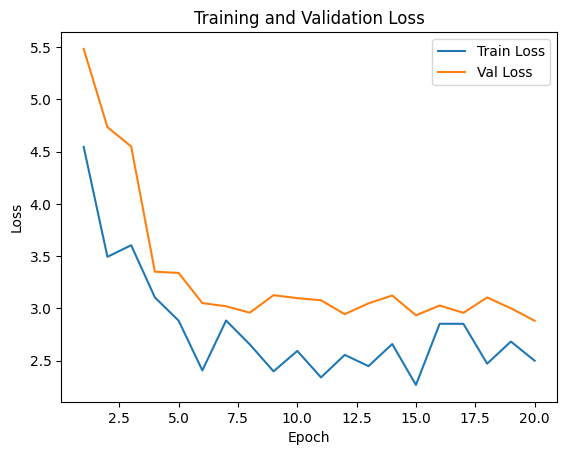

In [71]:
import os
import torch
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision.models.detection.ssdlite import SSDLite320_MobileNet_V3_Large_Weights
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt

# Assume your custom dataset class MyRatDataset is defined elsewhere.
# It should return images and targets (with keys: "boxes", "labels", etc.).

# --- Define transforms ---
transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# --- Create training and validation datasets and dataloaders ---
train_dataset = MyRatDatasetWithMosaic(root=dataset_root, transforms=transforms, mosaic_prob=0.8, mosaic_negative_prob=0.8)#MyRatDataset(root="new_dataset\\train", transforms=transforms, negative_sample_ratio=0.5)
val_dataset   = MyRatDatasetWithMosaic(root=dataset_root, transforms=transforms, mosaic_prob=0.5, mosaic_negative_prob=0.5)#MyRatDataset(root="new_dataset\\valid", transforms=transforms, negative_sample_ratio=0.3)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda batch: tuple(zip(*batch))
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=lambda batch: tuple(zip(*batch))
)

# --- Load and modify the SSDLite detection model ---
# weights=None -> no detection head weights loaded
# num_classes=2 -> background + rat
# weights_backbone -> pretrained backbone on ImageNet
# box_score_thresh, box_nms_thresh -> help reduce overlapping boxes
model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(
    weights=None,
    num_classes=2,
    weights_backbone=torchvision.models.MobileNet_V3_Large_Weights.IMAGENET1K_V1,
    box_score_thresh=0.5,   # e.g. only keep detections > 0.5 confidence
    box_nms_thresh=0.3      # e.g. more aggressive NMS
)

# --- Define optimizer and scheduler ---
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=0.0005
)
# StepLR reduces LR by gamma every 'step_size' epochs
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

# Set up TensorBoard logging
writer = SummaryWriter(log_dir="runs/ssdlite_rat_detection")

# We'll maintain only two checkpoints: best.pth (best val loss) and last.pth (current).
best_val_loss = float('inf')
loss_gap_threshold = 0.001  # threshold for improvement

# Save and validate every 5 epochs
save_interval = 5
validate_interval = 1

# Helper function to force BatchNorm layers to eval mode (for val loss)
def set_bn_eval(m):
    if isinstance(m, torch.nn.BatchNorm2d):
        m.eval()

# --- Training loop with validation ---
num_epochs = 20
train_losses = []
validation_losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(device)

for epoch in range(num_epochs):
    # ----------------- TRAIN ----------------- #
    model.train()
    epoch_train_loss = 0.0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        epoch_train_loss += losses.item()
    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Step the LR scheduler after each epoch
    scheduler.step()
    
    # -------------- LOG TRAIN LOSS -------------- #
    writer.add_scalar("Loss/Train", epoch_train_loss, epoch+1)
    
    # Optionally do validation every 'validate_interval' epochs
    if (epoch + 1) % validate_interval == 0:
        # -------------- VALIDATION -------------- #
        model.train()          # required for loss
        model.apply(set_bn_eval)  # but BN layers in eval mode
        epoch_val_loss = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                
                loss_dict = model(images, targets)
                val_losses = sum(loss for loss in loss_dict.values())
                epoch_val_loss += val_losses.item()
        epoch_val_loss /= len(val_loader)
        validation_losses.append(epoch_val_loss)
        
        # Log val loss
        writer.add_scalar("Loss/Val", epoch_val_loss, epoch+1)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
        
        # --- SAVE MODELS --- #
        # Always save 'last.pth' every 'save_interval' epochs (or at final epoch)
        if (epoch + 1) == num_epochs:
            torch.save(model.state_dict(), "runs/last.pth")
            print("Saved last.pth")
        
        # Update 'best.pth' if improvement is significant
        if epoch_val_loss < best_val_loss - loss_gap_threshold:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "runs/best.pth")
            print("New best model saved to best.pth")
        else:
            print("No significant improvement; best model remains unchanged.")
        
    else:
        # If no validation this epoch, just print training loss
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} (no validation)")

writer.close()

epochs = range(1, num_epochs + 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, validation_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


In [72]:
def predict(image_path, model, device, threshold=0.7):
        # Load image using PIL
        img = Image.open(image_path).convert("RGB")
        orig_img = np.array(img)  # For visualization
        # Apply transforms
        img_tensor = transforms(img).to(device)
        img_tensor = img_tensor.unsqueeze(0)
        
        model.eval()
        with torch.no_grad():
            outputs = model(img_tensor)
        output = outputs[0]
        boxes = output['boxes'].cpu().numpy()
        scores = output['scores'].cpu().numpy()
        labels = output['labels'].cpu().numpy()
        
        # Filter out detections below threshold
        keep = scores >= threshold
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]
        return orig_img, boxes, scores, labels

# SSD Image Predict

In [73]:
import cv2
import torch
import torchvision
import torchvision.transforms as T
import numpy as np
from PIL import Image

# Force using CPU or GPU as desired
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use the official backbone weights for MobileNetV3 Large
backbone_weights = torchvision.models.MobileNet_V3_Large_Weights.IMAGENET1K_V1

# For SSDLite, we set weights=None (to avoid loading detection head weights) and override num_classes=2.
model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(
    weights=None,         # Do not load COCO detection weights.
    num_classes=2,        # 2 classes: background and rat.
    weights_backbone=backbone_weights  # Load pretrained backbone.
)
model.to(device)

# Load your fine-tuned weights for SSDLite (ensure these were trained for num_classes=2)
model_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\FastRcNN\runs\best.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# For inference transforms, you can use the ones provided by the official weights.
# Here we use the default transforms from the backbone weights; you can also compose your own.
transform = T.Compose([
    T.ToTensor(),
    # If you need to normalize further, you could add normalization.
    # For SSDLite, images are expected to be scaled to [0, 1].
])

def predict(image_input, model, device, threshold=0.7):
    """
    Predict detections on a given image.
    
    Args:
        image_input (str or np.ndarray): If a string, treated as a file path; if an ndarray, assumed to be a BGR image.
        model: The detection model.
        device: The computation device.
        threshold (float): Confidence threshold.
    
    Returns:
        orig_img (np.ndarray): Original image in BGR format.
        boxes (np.ndarray): Bounding boxes.
        scores (np.ndarray): Confidence scores.
        labels (np.ndarray): Detected labels.
    """
    # Convert input to PIL image and get original for display
    if isinstance(image_input, np.ndarray):
        # image_input is a BGR frame
        pil_img = Image.fromarray(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB))
        orig_img = image_input.copy()
    elif isinstance(image_input, str):
        pil_img = Image.open(image_input).convert("RGB")
        # Convert to BGR for display
        orig_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    else:
        raise ValueError("Unsupported image_input type; must be str or np.ndarray.")
    
    # Apply transforms (convert PIL image to tensor)
    img_tensor = transform(pil_img).to(device)
    img_tensor = img_tensor.unsqueeze(0)  # add batch dimension
    
    with torch.no_grad():
        outputs = model(img_tensor)
    output = outputs[0]
    boxes = output['boxes'].cpu().numpy()
    scores = output['scores'].cpu().numpy()
    labels = output['labels'].cpu().numpy()
    
    # Filter detections below the threshold
    keep = scores >= threshold
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]
    
    return orig_img, boxes, scores, labels

# --- Inference on a test image ---
test_image_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\FastRcNN\new_dataset\test\images\Baseline_frame_000253.jpg"
orig_img, boxes, scores, labels = predict(test_image_path, model, device, threshold=0.7)

# Draw bounding boxes on the test image using OpenCV
for box, score, label in zip(boxes, scores, labels):
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(orig_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig_img, f"Rat: {score:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

cv2.imshow("Predictions", orig_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


# SSDLite VIdeo Predict

In [75]:
import cv2
import torch
import torchvision
import torchvision.transforms as T
import numpy as np
from PIL import Image
import torchvision.ops as ops  # for NMS

# Define the transform (same as used during training/inference)
transform = T.Compose([
    T.ToTensor(),
    # SSDLite models usually expect pixel values scaled to [0, 1]. 
    # Additional normalization can be added if needed.
])

# Force using CPU for inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the SSDLite model with MobileNetV3 Large backbone.
# Here, we initialize with no detection weights (weights=None) so we can set num_classes=2.
# We load pretrained backbone weights from MobileNet_V3_Large_Weights.
model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(
    weights=None,
    num_classes=2,  # 2 classes: background (0) and rat (1)
    weights_backbone=torchvision.models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
)
model.to(device)

# Load your fine-tuned SSDLite weights for rat detection.
model_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\FastRcNN\runs\best.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

def predict(image_input, model, device, threshold=0.7, iou_threshold=0.3):
    """
    Predict detections on a given image input.
    
    Args:
        image_input (str or np.ndarray): If string, treated as a file path;
                                           if np.ndarray, treated as an OpenCV BGR image.
        model: The SSDLite detection model.
        device: Computation device.
        threshold (float): Confidence threshold for filtering detections.
        iou_threshold (float): IoU threshold for non-max suppression.
    
    Returns:
        orig_img (np.ndarray): The original image in BGR format.
        boxes (np.ndarray): Array of final bounding boxes.
        scores (np.ndarray): Detection confidence scores.
        labels (np.ndarray): Detected labels.
        inference_time_ms (float): Inference time in milliseconds.
    """
    # Convert input to PIL image and get original image for display
    if isinstance(image_input, np.ndarray):
        # image_input is a frame in BGR format
        pil_img = Image.fromarray(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB))
        orig_img = image_input.copy()  # keep a copy in BGR for display
    elif isinstance(image_input, str):
        pil_img = Image.open(image_input).convert("RGB")
        orig_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    else:
        raise ValueError("Unsupported image_input type. Must be str or np.ndarray.")
    
    # Apply transforms to the PIL image
    img_tensor = transform(pil_img).to(device)
    img_tensor = img_tensor.unsqueeze(0)  # add batch dimension

    # Measure inference time using OpenCV ticks
    start = cv2.getTickCount()
    with torch.no_grad():
        outputs = model(img_tensor)
    end = cv2.getTickCount()
    inference_time_ms = (end - start) / cv2.getTickFrequency() * 1000.0

    output = outputs[0]
    boxes = output['boxes'].cpu().numpy()
    scores = output['scores'].cpu().numpy()
    labels = output['labels'].cpu().numpy()

    # Filter out detections below threshold
    keep = scores >= threshold
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    # Apply Non-Maximum Suppression (per class)
    if boxes.shape[0] > 0:
        final_boxes = []
        final_scores = []
        final_labels = []
        unique_labels = np.unique(labels)
        for cls in unique_labels:
            inds = np.where(labels == cls)[0]
            boxes_cls = torch.tensor(boxes[inds])
            scores_cls = torch.tensor(scores[inds])
            keep_inds = ops.nms(boxes_cls, scores_cls, iou_threshold)
            final_boxes.append(boxes_cls[keep_inds])
            final_scores.append(scores_cls[keep_inds])
            final_labels.append(torch.tensor([cls] * len(keep_inds)))
        if final_boxes:
            boxes = torch.cat(final_boxes).numpy()
            scores = torch.cat(final_scores).numpy()
            labels = torch.cat(final_labels).numpy()
    else:
        boxes = np.empty((0, 4))
        scores = np.empty((0,))
        labels = np.empty((0,))

    return orig_img, boxes, scores, labels, inference_time_ms

def main():
    video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\BaselineDark.mp4"
    # video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\Baseline.mp4"
    # video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\TestFile_video.mp4"
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video file: {video_path}")
        return

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Run prediction on the current frame (which is a numpy array in BGR format)
        orig_img, boxes, scores, labels, inf_time = predict(frame, model, device, threshold=0.4, iou_threshold=0.0)
        # print("Labels:", labels)
        print("Inference time (ms):", inf_time)

        # Draw bounding boxes and labels on the original image
        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(orig_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(orig_img, f"Rat: {score:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        # Draw inference time on the frame
        # cv2.putText(orig_img, f"Inference: {inf_time:.1f} ms", (10, 30),
        #             cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
        
        cv2.imshow("Predictions", orig_img)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


Inference time (ms): 23.7034
Inference time (ms): 30.2386
Inference time (ms): 36.7403
Inference time (ms): 32.644
Inference time (ms): 33.418000000000006
Inference time (ms): 24.3082
Inference time (ms): 20.921100000000003
Inference time (ms): 20.917
Inference time (ms): 22.6137
Inference time (ms): 22.9784
Inference time (ms): 23.2862
Inference time (ms): 22.2949
Inference time (ms): 22.0997
Inference time (ms): 21.1317
Inference time (ms): 22.287100000000002
Inference time (ms): 21.3687
Inference time (ms): 21.6505
Inference time (ms): 21.203799999999998
Inference time (ms): 21.8521
Inference time (ms): 23.3122
Inference time (ms): 30.283399999999997
Inference time (ms): 32.4539
Inference time (ms): 30.3461
Inference time (ms): 21.677
Inference time (ms): 23.8394
Inference time (ms): 20.9805
Inference time (ms): 21.186400000000003
Inference time (ms): 20.8518
Inference time (ms): 21.6901
Inference time (ms): 22.3544
Inference time (ms): 19.9049
Inference time (ms): 21.7377
Inference